In [ ]:
import pandas as pd
from pathlib import Path
import re
import numpy as np 
import os 
import datetime as dt 
from dataclasses import dataclass 

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import astropy 
import astroplan 
import twirl 
import photutils.aperture 
import lightkurve as lk 
import pytz 

import vao 




# Folders + filenames 

subset_data_folder =            Path.cwd() / "Observations" / "2025-06-28_V0451Dra" # Path to where subset of data is stored (same folder that this notebook is located)
# full_data_folder =              Path("D:/2025-06-28_V0451Dra_VariableStar") # Path to where full data is stored (external hard drive)


fits_folder =                   "D:/Observations_(Fits_Files)/2025-08-25_V0572Cam" 
bias_folder =                   fits_folder / "Biases"
dark_folder =                   fits_folder / "Darks"
flat_folder =                   fits_folder / "Flats"
raw_folder =                    fits_folder / "RawImages"
calibrated_folder =             fits_folder / "CalibratedImages" 




candidates_folder =             "D:/AAVSO_candidates" 
lightcurve_data_folder =        "D:/Lightkurve_lightcurves" 
plots_folder =                  subset_data_folder / "Plots" 

candidates_filename =           "AAVSO_candidates_3.csv" 
candidates_fullpath =           candidates_folder / candidates_filename 

master_bias_filename =          "master_bias.fits"
master_bias_fullpath =          bias_folder / master_bias_filename

master_dark_filename =          "master_dark.fits" 
master_dark_fullpath =          dark_folder / master_dark_filename 

master_flat_filename =          "master_flat.fits" 
master_flat_fullpath =          flat_folder / master_flat_filename 

VAO_lightcurve_filename =       "2025-06-28_V451Dra_Lightcurve.csv"
VAO_lightcurve_fullpath =       subset_data_folder / VAO_lightcurve_filename 



# Ra, dec positions of three stars analyzed 
target_position = (171.1046, 77.7043)
norm_star_position = (171.4224, 77.7134)
test_star_position = (171.3256, 77.6831)




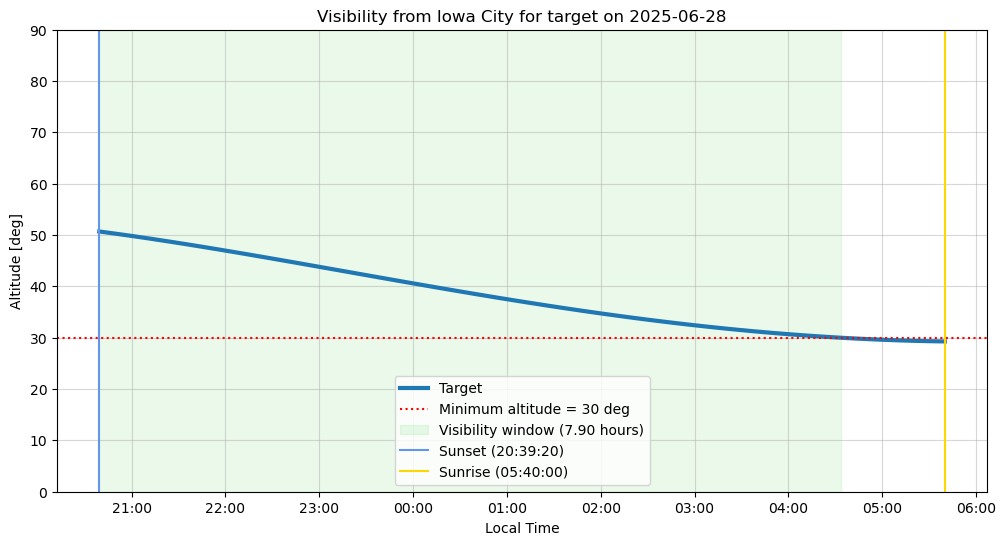

In [ ]:
# Try plotting the altitude vs time of any RA and dec coordinates for any night of observation

observer = vao.get_observer() 
target = vao_utils.get_target(coord_deg_tuple=(171.1046, 77.7043))

date = astropy.time.Time(dt.datetime(
    year=2025, 
    month=6, 
    day=28, 
    hour=16, # Must assign an hour that is after sunrise. Otherwise, the default value is midnight, so the calculation that finds the next sunset and sunrise will use the wrong observing period 
    tzinfo=pytz.timezone("US/Central"))) 

min_alt = 30 

visibility = vao_utils.calc_visibility(
    observer=observer, 
    target=target, 
    date=date, 
    min_alt=min_alt)

vao_utils.plot_target_altitude(visibility=visibility) 



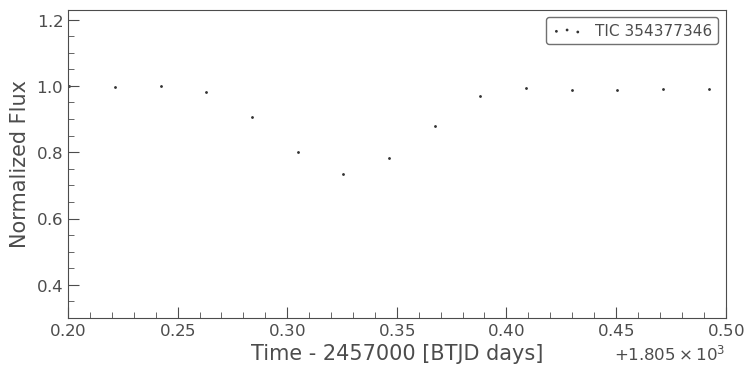

In [67]:

search_arr = lk.search_lightcurve("347.27063069896 +77.70400021056") 
# search_arr = lk.search_lightcurve("V451 Dra") 
# print(search_arr) 

search = search_arr[0]
# print(search) 

lc = search.download(download_dir=str(lightcurve_data_folder)) 
lc.scatter() 
plt.xlim((1805.2, 1805.5))
# plt.ylim((0.96, 1.02))

# lc_folded = lc.fold(period=11.7 - 8.75) 
# lc_folded.scatter() 
plt.show() 


# period = np.linspace(0.04, 0.06, 5000)
# bls = lc_folded.to_periodogram(method='lombscargle', period=period) 
# bls.plot()  

0.014850708333333332